In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering 

# ------------------------------
# 1. Generate synthetic dataset
# ------------------------------
np.random.seed(42)
n_customers = 500
n_per_segment = 100

customer_id = np.arange(1, n_customers + 1)
gender = np.random.choice(['Male', 'Female'], n_customers)
age = np.random.randint(18, 70, n_customers)

annual_income = np.concatenate([
    np.random.normal(20, 5, n_per_segment),  # Low Income
    np.random.normal(20, 8, n_per_segment), # Mid-Low Income
    np.random.normal(80, 10, n_per_segment), # High Income
    np.random.normal(25, 5, n_per_segment), # Low Income (variant)
    np.random.normal(85, 10, n_per_segment), # Very High Income
])

spending_score = np.concatenate([
    np.random.normal(80, 10, n_per_segment),  # High Spend
    np.random.normal(50, 10, n_per_segment),  # Mid Spend
    np.random.normal(15, 10, n_per_segment),  # Low Spend
    np.random.normal(20, 10, n_per_segment),  # Low Spend
    np.random.normal(85, 10, n_per_segment),  # High Spend
])
df = pd.DataFrame({
    'CustomerID': customer_id,
    'Gender': gender,
    'Age': age,
    'Annual_Income': annual_income.astype(int),
    'Spending_Score': np.clip(spending_score, 1, 100).astype(int)
})

# Save to CSV
df.to_csv('customers.csv', index = False)

print("Synthetic dataset saved as 'customer_data.csv'")
print(df.head())
print(df.describe())

Synthetic dataset saved as 'customer_data.csv'
   CustomerID  Gender  Age  Annual_Income  Spending_Score
0           1    Male   38             18              65
1           2  Female   49             23              58
2           3    Male   40             27              84
3           4    Male   50             20              74
4           5    Male   20             28              69
       CustomerID         Age  Annual_Income  Spending_Score
count  500.000000  500.000000      500.00000      500.000000
mean   250.500000   43.800000       45.81400       50.126000
std    144.481833   14.835504       31.28176       30.725857
min      1.000000   18.000000        0.00000        1.000000
25%    125.750000   31.000000       20.00000       20.000000
50%    250.500000   44.000000       28.00000       52.000000
75%    375.250000   56.000000       79.00000       79.000000
max    500.000000   69.000000      110.00000      100.000000


# Data Preparation and Cleaning

In [37]:
# Step 1: Select Feature for Clustering Annual Income and Spending Score 
X = df[['Annual_Income', 'Spending_Score']].values

In [38]:
# Step 2: Feature Scaling 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

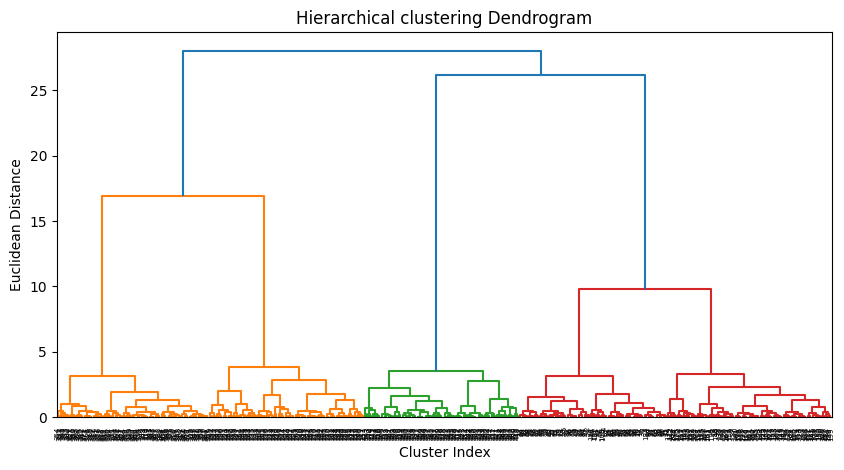

In [39]:
# Step 3: Determine Clusters (Dendrogram)
plt.figure(figsize=(10,5))
linked_matrix = sch.linkage(X_scaled, method='ward')
dendrogtram =  sch.dendrogram(linked_matrix)
plt.title("Hierarchical clustering Dendrogram")
plt.xlabel("Cluster Index")
plt.ylabel("Euclidean Distance")
plt.show()

In [40]:
# Step 4: Building the Model
hc = AgglomerativeClustering(n_clusters=5, metric = "euclidean", linkage="ward")
cluster_labels= hc.fit_predict(X_scaled)

# add lables
df['Cluster'] = cluster_labels

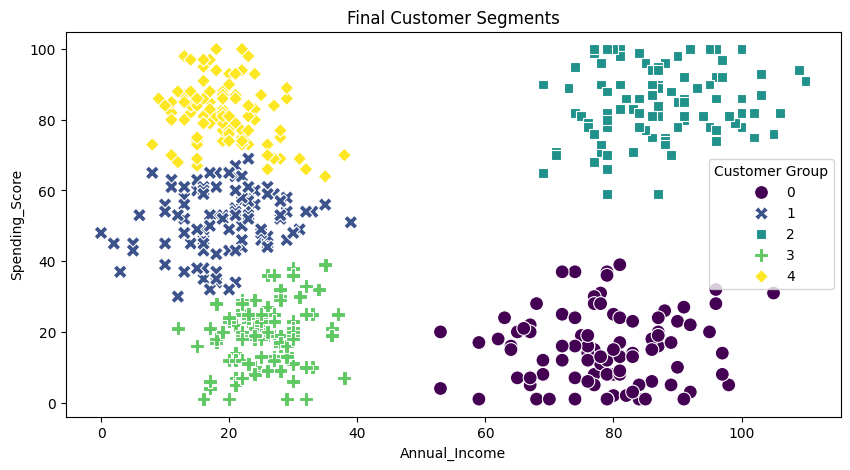

The Silhouette Score for the model is: 0.60


In [41]:
# Step 5: Visualize and Valiating Solution
plt.figure(figsize=(10,5))
sns.scatterplot(
                x=df['Annual_Income'], 
                y=df['Spending_Score'],
                hue = df['Cluster'],
                palette = 'viridis',
                s=100,
                style = df['Cluster']
               )
plt.title("Final Customer Segments")
plt.legend(title="Customer Group")
plt.show()

# Validate
score = silhouette_score(X_scaled, cluster_labels)
print(f"The Silhouette Score for the model is: {score:.2f}")

In [42]:
# Identify Top-Spending Customers for the Marketing Team 
"""
based on our cluster analysis, Cluster 2 represents the "The Elite" customers. 
"""
# Filter the DataFrame to get customers in Cluster 2(The Elite)
the_elite_customers = df[df['Cluster']==2]

print(f"Numbers of Elite Customers (Cluster 2) : {len(the_elite_customers)}")

# Save The ELite Customers to CSV file
the_elite_customers.to_csv("the_elite_customers.csv")
print("Elite Customers List Saved to 'the_elite_customers.csv' successfully." )

Numbers of Elite Customers (Cluster 2) : 100
Elite Customers List Saved to 'the_elite_customers.csv' successfully.


In [ ]:
# Complete code:
"""
1. Create 5 Cluster based on Spending Score and Annual Income.
2. Save seperate customers to seperate csv. 
"""